# Dataset Pre-Process and Feature Discussion

## Data Set and Pre-Processing

In [1]:
%pip install kagglehub


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import kagglehub
#this is the UNSW_NB15 dataset which is more modern
path = kagglehub.dataset_download("mrwellsdavid/unsw-nb15")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\Owner\.cache\kagglehub\datasets\mrwellsdavid\unsw-nb15\versions\1


In [3]:
#inspect files
import os
os.listdir(path)
#we see all of the fils that we could've downloaded on kaggle

['NUSW-NB15_features.csv',
 'UNSW-NB15_1.csv',
 'UNSW-NB15_2.csv',
 'UNSW-NB15_3.csv',
 'UNSW-NB15_4.csv',
 'UNSW-NB15_LIST_EVENTS.csv',
 'UNSW_NB15_testing-set.csv',
 'UNSW_NB15_training-set.csv']

In [4]:
%pip install pandas

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
#but we really only want the training and testing set
import pandas as pd
train_df = pd.read_csv(os.path.join(path, "UNSW_NB15_training-set.csv"))
test_df = pd.read_csv(os.path.join(path, "UNSW_NB15_testing-set.csv"))

#for OUR project we want to combine both of these because more data = better feature learning, and clustering benefits from more samples

df_og = pd.concat([train_df, test_df], axis = 0)

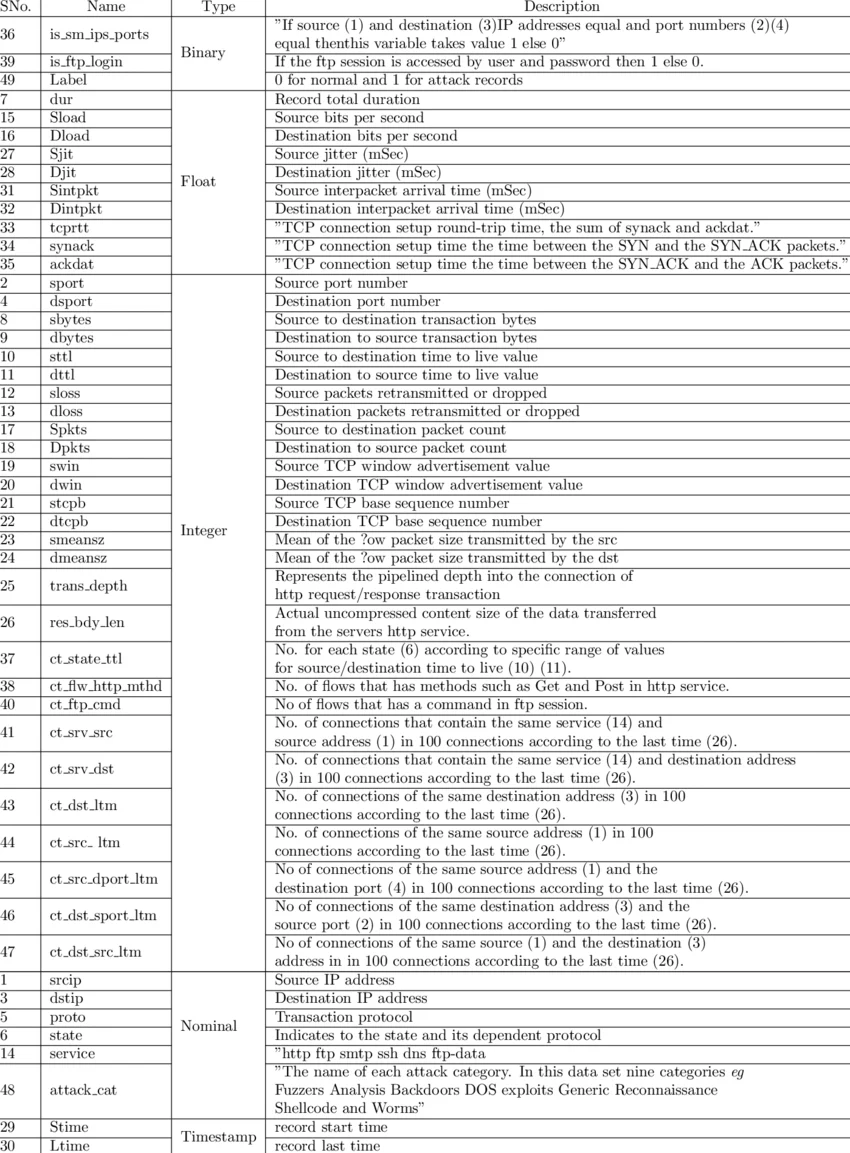

In [6]:
from IPython.display import Image
Image('C:\\Users\\Owner\\Documents\\aiProject\\image.png')

#THIS IS ALL OF THE COLUMNS, THEIR TYPE, AND A DESCRIPTION

In [7]:
print(df_og['label'].value_counts())
print(df_og['attack_cat'].value_counts())

#this is the names of the types of attacks, and I believe the number of them that occur in the dataset.

label
1    164673
0     93000
Name: count, dtype: int64
attack_cat
Normal            93000
Generic           58871
Exploits          44525
Fuzzers           24246
DoS               16353
Reconnaissance    13987
Analysis           2677
Backdoor           2329
Shellcode          1511
Worms               174
Name: count, dtype: int64


There are columns of data that we do not need. NOTE that some of  the data was preprocessed prior to my downloading of the dataset. There were 4 removed columns of data.

The columns of data that we do not need are "ID" and "label"

In [8]:
#we want to see what column numbers correlate to the columns that we are wanting to drop
columns = df_og.columns
i=0
for column in columns:
  print(f"column number {i}: is {column}" )
  i+=1


column number 0: is id
column number 1: is dur
column number 2: is proto
column number 3: is service
column number 4: is state
column number 5: is spkts
column number 6: is dpkts
column number 7: is sbytes
column number 8: is dbytes
column number 9: is rate
column number 10: is sttl
column number 11: is dttl
column number 12: is sload
column number 13: is dload
column number 14: is sloss
column number 15: is dloss
column number 16: is sinpkt
column number 17: is dinpkt
column number 18: is sjit
column number 19: is djit
column number 20: is swin
column number 21: is stcpb
column number 22: is dtcpb
column number 23: is dwin
column number 24: is tcprtt
column number 25: is synack
column number 26: is ackdat
column number 27: is smean
column number 28: is dmean
column number 29: is trans_depth
column number 30: is response_body_len
column number 31: is ct_srv_src
column number 32: is ct_state_ttl
column number 33: is ct_dst_ltm
column number 34: is ct_src_dport_ltm
column number 35: is c

so we know that column's 0, 43, and 44 are the ID, attack_cat, and label, respectively. So we can drop these for our new dataset.

In [9]:
#df.drop removes columns that we do not need
df_new = df_og.drop(df_og.columns[[0, 43,44]], axis=1, inplace=False)
print(df_new)

             dur proto service state  spkts  dpkts  sbytes  dbytes  \
0       0.000011   udp       -   INT      2      0     496       0   
1       0.000008   udp       -   INT      2      0    1762       0   
2       0.000005   udp       -   INT      2      0    1068       0   
3       0.000006   udp       -   INT      2      0     900       0   
4       0.000010   udp       -   INT      2      0    2126       0   
...          ...   ...     ...   ...    ...    ...     ...     ...   
175336  0.000009   udp     dns   INT      2      0     114       0   
175337  0.505762   tcp       -   FIN     10      8     620     354   
175338  0.000009   udp     dns   INT      2      0     114       0   
175339  0.000009   udp     dns   INT      2      0     114       0   
175340  0.000009   udp     dns   INT      2      0     114       0   

                 rate  sttl  ...  ct_dst_ltm  ct_src_dport_ltm  \
0        90909.090200   254  ...           1                 1   
1       125000.000300   254

In [10]:
#we can now check to see that we no longer have an ID, attack cat, or a Label column. df.shape tells us we have two less columns than before
columns = df_new.columns
i=0
for column in columns:
  print(f"column number {i}: is {column}" )
  i+=1

column number 0: is dur
column number 1: is proto
column number 2: is service
column number 3: is state
column number 4: is spkts
column number 5: is dpkts
column number 6: is sbytes
column number 7: is dbytes
column number 8: is rate
column number 9: is sttl
column number 10: is dttl
column number 11: is sload
column number 12: is dload
column number 13: is sloss
column number 14: is dloss
column number 15: is sinpkt
column number 16: is dinpkt
column number 17: is sjit
column number 18: is djit
column number 19: is swin
column number 20: is stcpb
column number 21: is dtcpb
column number 22: is dwin
column number 23: is tcprtt
column number 24: is synack
column number 25: is ackdat
column number 26: is smean
column number 27: is dmean
column number 28: is trans_depth
column number 29: is response_body_len
column number 30: is ct_srv_src
column number 31: is ct_state_ttl
column number 32: is ct_dst_ltm
column number 33: is ct_src_dport_ltm
column number 34: is ct_dst_sport_ltm
column n

Now that we have handled dropping some columns, we have the issue of having some categorical columns as well. Proto, Service, and State, columns 1,2,3 respectively

Since we are doing a k-means implementation, these categorical values will not work. We could try "One-Hot Encoding" but this method will drastically increase our dimensionality. This is a problem because it ruins the spatial patterns and makes clustering difficult.

There exists an alternative, called k-prototype, which combine k-means, and k-modes methods in order to handle datasets that have both numerical and categorical values. This method used Euclidean distance for continuous data and matching dissimilarity for categorical data.

Since we are using a clustering-based unsupervised IDS, we need to be able to handle distance from a baseline considering both numerical and categorical features.

## Feature Values

**Basic Connection Features**  
- **dur** → Duration of the connection (how long the session lasts)  
- **proto** → Network protocol used (e.g., TCP, UDP)  
- **service** → Application-level service (e.g., HTTP, FTP, or “-” if unknown)  
- **state** → Connection state (status of the session, e.g., established, interrupted)  
----------------------------------------------------------

**Packet Counts & Volume**  
- **spkts** → Number of packets sent from source → destination  
- **dpkts** → Number of packets sent from destination → source  
- **sbytes** → Bytes sent from source → destination  
- **dbytes** → Bytes sent from destination → source  
----------------------------------------------------------

**Rate & TTL**  
- **rate** → Transmission rate (packets or bytes per second)  
- **sttl** → Source Time-To-Live (TTL value of packets sent)  
- **dttl** → Destination TTL (TTL of response packets)  
------------------------------------------------------------

**Load (Traffic Intensity)**  
- **sload** → Source data rate (bits per second sent)  
- **dload** → Destination data rate (bits per second received)  
--------------------------------------------------------------

**Packet Loss**  
- **sloss** → Number of packets lost from source  
- **dloss** → Number of packets lost from destination  
------------------------------------------------------------------

**Timing Between Packets**  
- **sinpkt** → Time between packets sent from source  
- **dinpkt** → Time between packets sent from destination  
-------------------------------------------------------------------------

**Jitter (Variation in Timing)**  
- **sjit** → Jitter in source packets (variation in send timing)  
- **djit** → Jitter in destination packets  
---------------------------------------------------------------

**TCP Window / Buffer Info**  
- **swin** → Source TCP window size  
- **stcpb** → Source TCP base sequence number  
- **dtcpb** → Destination TCP base sequence number  
- **dwin** → Destination TCP window size  
----------------------------------------------------------------

**TCP Timing Metrics**  
- **tcprtt** → TCP round-trip time (latency)  
- **synack** → Time between SYN and SYN-ACK  
- **ackdat** → Time between ACK and data transmission  
----------------------------------------------------------------------

**Packet Size Statistics**  
- **smean** → Mean packet size from source  
- **dmean** → Mean packet size from destination  
---------------------------------------------------------------------

**Application Layer Features**  
- **trans_depth** → Depth of HTTP transaction (number of request/response steps)  
- **response_body_len** → Size of HTTP response body  
---------------------------------------------------------------------------

**Connection Count Features**  
- **ct_srv_src** → Number of connections to same service from source  
- **ct_state_ttl** → Count of connections with same state and TTL  
- **ct_dst_ltm** → Connections to same destination over time  
- **ct_src_dport_ltm** → Connections from source to same destination port over time  
- **ct_dst_sport_ltm** → Connections to destination from same source port  
- **ct_dst_src_ltm** → Connections between same source-destination pair  
-------------------------------------------------------------

**Protocol-Specific Indicators**  
- **is_ftp_login** → Whether FTP login was attempted (1 = yes, 0 = no)  
- **ct_ftp_cmd** → Number of FTP commands used  
- **ct_flw_http_mthd** → Number of HTTP methods (GET, POST, etc.) used  
--------------------------------------------------------------------

**More Connection Counts**  
- **ct_src_ltm** → Connections from same source over time  
- **ct_srv_dst** → Connections to same service and destination  
---------------------------------------------------------------------

**Special Condition Feature**  
- **is_sm_ips_ports** → Whether source and destination IP/port are the same (can indicate unusual or suspicious behavior)


## How to read an outputted cluster:

We can take a look at an example of an outputted cluster below. This cluster comes from k-prototypes, but the general process is the same.

```
[['1.124618505561206' '7.205922196010018' '4.67776169802219'
  '2479.375532779573' '3633.7761631941003' '154809.83611611451'
  '211.34869720939145' '19.301607755288146' '119935511.2779037'
  '203383.78165217768' '1.1212854112562693' '1.6269254405963167'
  '1460.7006264723957' '41.719650875204955' '1084.295227184023'
  '122.64325003109145' '28.129010302057107' '61528538.68715844'
  '59990830.51575045' '23.91484117386621' '0.008550287836435973'
  '0.004350772786445351' '0.004199515049991582' '111.90265580291947'
  '34.68442928982548' '0.020749492826887112' '429.8105716683517'
  '13.175108538350218' '1.7508210587527837' '8.569864335322377'
  '7.92174665794395' '6.121516695411983' '12.364609559304562'
  '0.002768801749829841' '0.002768801749829841' '0.024185714568919374'
  '9.387077163002465' '13.01782870434616' '0.024284836349939536' 'udp'
  '-' 'INT']
  ```


Each entry in the above output is best thought of as a value representing each of our feature values. (For k-prototypes this is the mean for numerical and mode for categorical. K-means is all mean, and k-mode is all mode, intutively). So for the above outputted cluster we could organize it as follows...
  
- column 0: dur : 1.124618505561206  
- column 1: spkts : 7.205922196010018  
- column 2: dpkts : 4.67776169802219  
- column 3: sbytes : 2479.375532779573  
- column 4: dbytes : 3633.7761631941003  
- column 5: rate : 154809.83611611451  
- column 6: sttl : 211.34869720939145  
- column 7: dttl : 19.301607755288146  
- column 8: sload : 119935511.2779037  
- column 9: dload : 203383.78165217768  
- column 10: sloss : 1.1212854112562693  
- column 11: dloss : 1.6269254405963167  
- column 12: sinpkt : 1460.7006264723957  
- column 13: dinpkt : 41.719650875204955  
- column 14: sjit : 1084.295227184023  
- column 15: djit : 122.64325003109145  
- column 16: swin : 28.129010302057107  
- column 17: stcpb : 61528538.68715844  
- column 18: dtcpb : 59990830.51575045  
- column 19: dwin : 23.91484117386621  
- column 20: tcprtt : 0.008550287836435973  
- column 21: synack : 0.004350772786445351  
- column 22: ackdat : 0.004199515049991582  
- column 23: smean : 111.90265580291947  
- column 24: dmean : 34.68442928982548  
- column 25: trans_depth : 0.020749492826887112  
- column 26: response_body_len : 429.8105716683517  
- column 27: ct_srv_src : 13.175108538350218  
- column 28: ct_state_ttl : 1.7508210587527837  
- column 29: ct_dst_ltm : 8.569864335322377  
- column 30: ct_src_dport_ltm : 7.92174665794395  
- column 31: ct_dst_sport_ltm : 6.121516695411983  
- column 32: ct_dst_src_ltm : 12.364609559304562  
- column 33: is_ftp_login : 0.002768801749829841  
- column 34: ct_ftp_cmd : 0.002768801749829841  
- column 35: ct_flw_http_mthd : 0.024185714568919374  
- column 36: ct_src_ltm : 9.387077163002465  
- column 37: ct_srv_dst : 13.01782870434616  
- column 38: is_sm_ips_ports : 0.024284836349939536  
- column 39: proto : udp  
- column 40: service : -  
- column 41: state : INT  

Each value from the cluster output corresponds with some feature. To see what each feature means look at the notebook above. 

Each of the "datapoints" that are in our set have the above 42 values. This cluster (and all clusters in essence) will return the average of all included datapoints for each feature. For categorical values (proto, service, state), we will return the mode, which is just which value appears most frequently

**A cluster is a feature space where similar behaviors exist... and the centroid is the "center" of that behavior.

# Basic (Common) Solutions: K-means, K-mode, K-prototype

## K-Prototypes Model

### Running the Model

In [11]:
#we will be using the KModes library "off-the-shelf" version of Kprototype for now

%pip install kmodes

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [12]:
%pip install numpy

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [13]:
import numpy
import kmodes
from kmodes.kprototypes import KPrototypes

df_kproto = df_new.copy() #create a new copy of the dataframe to work with for KPrototypes
categorical_cols = [1,2,3] #these are the remaining categorical columns in the dataframe, which are the protocol, service, and state columns. We need to specify these for KPrototypes so it knows how to handle them.

df_kproto.iloc[:, categorical_cols] = df_kproto.iloc[:, categorical_cols].astype(str) #convert the categorical columns to string type for KPrototypes
data_np = df_kproto.to_numpy() #convert the dataframe to a numpy array for KPrototypes

#initialize our model using 5 clusters (lower for run sake), using the Huang Variation, and n_init to 5 (which is how many times the algorithm will re run with different initial prototypes)
kproto = KPrototypes(n_clusters=5, init='Huang', n_init=5, verbose=1)

clusters = kproto.fit_predict(data_np, categorical=categorical_cols)

#store results and print
df_kproto_results = df_kproto.copy() #copy the dataframe to a new one to store the results in
df_kproto_results['cluster'] = clusters #add a new column to the dataframe with the cluster assignments
print(kproto.cluster_centroids_) #print the cluster centroids

Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run: 1, iteration: 1/100, moves: 28097, ncost: 1.2053348925180945e+23
Run: 1, iteration: 2/100, moves: 18623, ncost: 1.0750314338754998e+23
Run: 1, iteration: 3/100, moves: 15725, ncost: 9.757676237679014e+22
Run: 1, iteration: 4/100, moves: 9541, ncost: 9.483591950097803e+22
Run: 1, iteration: 5/100, moves: 5002, ncost: 9.402949658314728e+22
Run: 1, iteration: 6/100, moves: 3186, ncost: 9.366464688231026e+22
Run: 1, iteration: 7/100, moves: 2269, ncost: 9.345647219204946e+22
Run: 1, iteration: 8/100, moves: 1745, ncost: 9.333414369669311e+22
Run: 1, iteration: 9/100, moves: 1417, ncost: 9.325326448001555e+22
Run: 1, iteration: 10/100, moves: 1157, ncost: 9.319464234754047e+22
Run: 1, iteration: 11/100, moves: 925, ncost: 9.315460640456711e+22
Run: 1, iteration: 12/100, moves: 735, ncost: 9.31291312545892e+22
Run: 1, iteration: 13/100, moves: 677, ncost: 9.310449368476846e+22
Run: 1, iteration: 14/100, move

### Results

In [14]:
import pandas as pd
k_proto_labels = df_og['attack_cat']

#create a small analysis data frame so that we can verify what clusters are labelled anomalous and which are not, and to see if there are any patterns in the clusters that we can use to label them as anomalous or not

k_proto_resultDF = pd.DataFrame({
    'cluster': pd.Series(clusters).reset_index(drop=True), #the reset index stuff was just to make sure that the indexes of the clusters and the labels match up, since we dropped some columns and concatenated some dataframes, we want to make sure that the indexes are correct
    'attack_cat': k_proto_labels.reset_index(drop=True)
})

pd.crosstab(
    k_proto_resultDF['cluster'],
    k_proto_resultDF['attack_cat'],
    normalize='index'
)

attack_cat,Analysis,Backdoor,DoS,Exploits,Fuzzers,Generic,Normal,Reconnaissance,Shellcode,Worms
cluster,,,,,,,,,,
0,0.004996,0.002357,0.027019,0.221960,0.127568,0.007775,0.542605,0.058085,0.006649,0.000985
1,0.005206,0.002846,0.028183,0.235874,0.127968,0.008365,0.524052,0.060114,0.006352,0.001041
2,0.005894,0.002966,0.028571,0.241637,0.138502,0.009011,0.506214,0.060071,0.005744,0.001389
3,0.005196,0.002910,0.026917,0.219559,0.124329,0.008764,0.549035,0.055253,0.006305,0.001732
4,0.014337,0.013917,0.091317,0.128651,0.066616,0.399600,0.228696,0.051119,0.005547,0.000200


In [15]:
# Group by cluster and summarize attack categories
agg_dict = {
    'attack_cat': lambda x: x.mode()[0] # Most common attack type in each cluster
}
cluster_summary = k_proto_resultDF.groupby('cluster').agg(agg_dict)
print("Most common attack category per cluster:")
print(cluster_summary)

# In-depth summary: count, unique attack types, and proportions per cluster
summary_stats = k_proto_resultDF.groupby('cluster').agg({
    'attack_cat': ['count', lambda x: x.nunique(), lambda x: x.value_counts(normalize=True).to_dict()]
})
summary_stats.columns = ['count', 'unique_attack_types', 'attack_cat_distribution']
print("\nDetailed cluster statistics:")
print(summary_stats)

# Crosstab for full distribution of attack categories per cluster
crosstab = pd.crosstab(k_proto_resultDF['cluster'], k_proto_resultDF['attack_cat'], normalize='index')
print("\nProportion of each attack category in each cluster:")
print(crosstab)

Most common attack category per cluster:
        attack_cat
cluster           
0           Normal
1           Normal
2           Normal
3           Normal
4          Generic

Detailed cluster statistics:
          count  unique_attack_types  \
cluster                                
0         28424                   10   
1         28812                   10   
2         26635                   10   
3         28867                   10   
4        144935                   10   

                                   attack_cat_distribution  
cluster                                                     
0        {'Normal': 0.5426048409794539, 'Exploits': 0.2...  
1        {'Normal': 0.5240524781341108, 'Exploits': 0.2...  
2        {'Normal': 0.5062136286840623, 'Exploits': 0.2...  
3        {'Normal': 0.5490352305400631, 'Exploits': 0.2...  
4        {'Generic': 0.3995998206092386, 'Normal': 0.22...  

Proportion of each attack category in each cluster:
attack_cat  Analysis  Backdoor     

### Visualization

In [16]:
%pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [17]:
import matplotlib.pyplot as plt

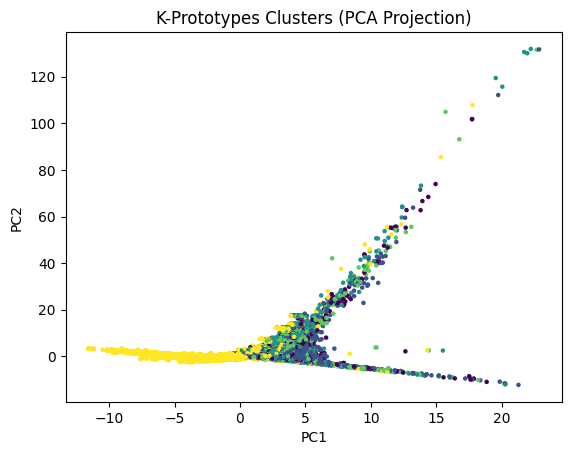

In [18]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
# redefine categorical_cols as column names for correct selection
categorical_cols = ['proto', 'service', 'state']

# select only numerical columns
X_num = df_kproto.loc[:, ~df_kproto.columns.isin(categorical_cols)]
# scale
X_scaled = StandardScaler().fit_transform(X_num)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)


plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, s=5)
plt.title("K-Prototypes Clusters (PCA Projection)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

## K-Means Model

### Running the Model

In [19]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

df_kmeans = df_new.copy()  # create a new copy of the dataframe to work with for KMeans

# KMeans cannot handle categorical columns directly, so we remove protocol, service, and state
df_kmeans = df_kmeans.drop(columns=['proto', 'service', 'state'])

# scale the numeric data so large-value columns do not dominate the clustering
scaler = StandardScaler()
data_kmeans = scaler.fit_transform(df_kmeans)

# initialize our model using 5 clusters and n_init=10 so it reruns with different centroid starts
kmeans = KMeans(n_clusters=5, n_init=10, random_state=42)

kmeans_clusters = kmeans.fit_predict(data_kmeans)

# store results and print
df_kmeans_results = df_kmeans.copy()
df_kmeans_results['cluster'] = kmeans_clusters

print(kmeans.cluster_centers_)

[[ 1.62412385e-02  9.63150437e-02  1.78327773e-01  1.15057662e-02
   1.16911071e-01 -5.63958057e-01 -4.26721177e-01  8.14574065e-01
  -3.77861834e-01  2.91916642e-01  4.26281385e-02  1.45064563e-01
  -1.12782018e-01  7.35591793e-02  1.26141276e-01  1.52584004e-01
   1.04602660e+00  8.37333274e-01  8.37122964e-01  1.06654553e+00
   5.68444776e-01  5.05198334e-01  5.59422280e-01  1.88636169e-01
   5.14784673e-01  1.72537012e-01  4.75800746e-02 -4.88670741e-01
  -6.16355011e-01 -4.38575475e-01 -4.66073281e-01 -5.09669301e-01
  -5.17491469e-01 -1.10418786e-01 -1.10225481e-01  2.32155090e-01
  -4.39011698e-01 -5.01832428e-01 -1.20335365e-01]
 [-1.88430035e-01 -1.30268510e-01 -1.65327909e-01 -4.84370833e-02
  -9.84088216e-02  7.54332785e-01  7.14726992e-01 -7.51487925e-01
   2.49568150e-01 -2.72849666e-01 -7.37000759e-02 -1.25575104e-01
  -1.28118195e-01 -9.04096811e-02 -1.09695250e-01 -1.48148662e-01
  -9.34416050e-01 -7.35576714e-01 -7.34817567e-01 -9.37230168e-01
  -4.95486316e-01 -4.3914

### Results

In [20]:
import pandas as pd
k_means_labels = df_og['attack_cat']

# create a small analysis dataframe so we can compare KMeans clusters to the actual attack categories
k_means_resultDF = pd.DataFrame({
    'cluster': pd.Series(kmeans_clusters).reset_index(drop=True),
    'attack_cat': k_means_labels.reset_index(drop=True)
})

pd.crosstab(
    k_means_resultDF['cluster'],
    k_means_resultDF['attack_cat'],
    normalize='index'
)


attack_cat,Analysis,Backdoor,DoS,Exploits,Fuzzers,Generic,Normal,Reconnaissance,Shellcode,Worms
cluster,,,,,,,,,,
0,0.005309,0.002757,0.028089,0.218325,0.130892,0.008586,0.538890,0.059446,0.006401,0.001306
1,0.000291,0.000291,0.000333,0.000770,0.012336,0.947557,0.038318,0.000083,0.000021,0.000000
2,0.000000,0.000000,0.007088,0.544838,0.042527,0.000000,0.405547,0.000000,0.000000,0.000000
3,0.000000,0.000000,0.182609,0.817391,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,0.022913,0.022363,0.145964,0.191363,0.091819,0.138251,0.299774,0.078786,0.008532,0.000236


In [21]:
# Group by cluster and summarize attack categories
agg_dict = {
    'attack_cat': lambda x: x.mode()[0]  # Most common attack type in each cluster
}
kmeans_cluster_summary = k_means_resultDF.groupby('cluster').agg(agg_dict)
print("Most common attack category per cluster:")
print(kmeans_cluster_summary)

# In-depth summary: count, unique attack types, and proportions per cluster
kmeans_summary_stats = k_means_resultDF.groupby('cluster').agg({
    'attack_cat': ['count', lambda x: x.nunique(), lambda x: x.value_counts(normalize=True).to_dict()]
})
kmeans_summary_stats.columns = ['count', 'unique_attack_types', 'attack_cat_distribution']
print("\nDetailed cluster statistics:")
print(kmeans_summary_stats)

# Crosstab for full distribution of attack categories per cluster
kmeans_crosstab = pd.crosstab(k_means_resultDF['cluster'], k_means_resultDF['attack_cat'], normalize='index')
print("\nProportion of each attack category in each cluster:")
print(kmeans_crosstab)

Most common attack category per cluster:
        attack_cat
cluster           
0           Normal
1          Generic
2         Exploits
3         Exploits
4           Normal

Detailed cluster statistics:
          count  unique_attack_types  \
cluster                                
0        117165                   10   
1         48071                    9   
2          3245                    4   
3           115                    2   
4         89077                   10   

                                   attack_cat_distribution  
cluster                                                     
0        {'Normal': 0.5388896001365595, 'Exploits': 0.2...  
1        {'Generic': 0.9475567389902436, 'Normal': 0.03...  
2        {'Exploits': 0.5448382126348228, 'Normal': 0.4...  
3        {'Exploits': 0.8173913043478261, 'DoS': 0.1826...  
4        {'Normal': 0.2997743525264659, 'Exploits': 0.1...  

Proportion of each attack category in each cluster:
attack_cat  Analysis  Backdoor     

### Visualization

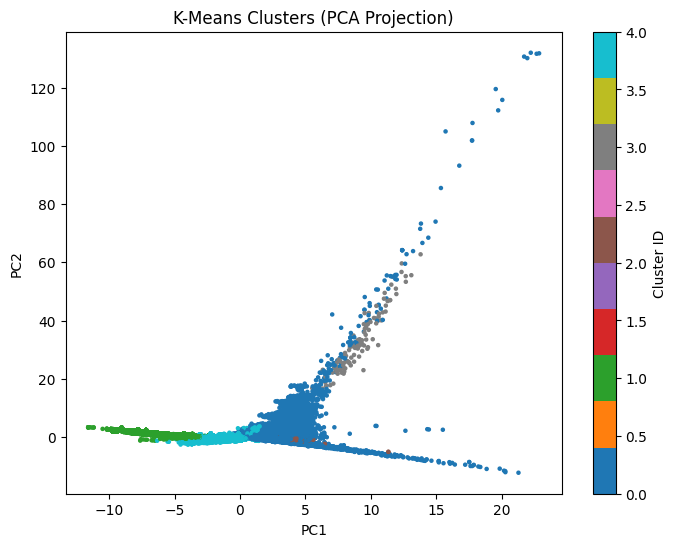

In [22]:
# Visualize K-Means Clusters using PCA
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# PCA for 2D projection of KMeans results
pca = PCA(n_components=2)
X_kmeans_pca = pca.fit_transform(data_kmeans)

plt.figure(figsize=(8,6))
plt.scatter(X_kmeans_pca[:, 0], X_kmeans_pca[:, 1], c=kmeans_clusters, s=5, cmap='tab10')
plt.title("K-Means Clusters (PCA Projection)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label="Cluster ID")
plt.show()

## K-Mode Model

### Running the Model

In [23]:
import pandas as pd
from kmodes.kmodes import KModes

df_kmodes = df_new[['proto', 'service', 'state']].copy()  # K-Modes only works with categorical features

# make sure everything is treated as strings
df_kmodes = df_kmodes.astype(str)

# initialize our model using 5 clusters and Huang initialization
kmode = KModes(n_clusters=5, init='Huang', n_init=5, verbose=1)

kmodes_clusters = kmode.fit_predict(df_kmodes)

# store results and print
df_kmodes_results = df_kmodes.copy()
df_kmodes_results['cluster'] = kmodes_clusters

print(kmode.cluster_centroids_)

Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 1, iteration: 1/100, moves: 1641, cost: 99184.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 2, iteration: 1/100, moves: 11398, cost: 98022.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 3, iteration: 1/100, moves: 0, cost: 102831.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 4, iteration: 1/100, moves: 57565, cost: 103468.0
Run 4, iteration: 2/100, moves: 0, cost: 103468.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 5, iteration: 1/100, moves: 0, cost: 82896.0
Best run was number 5
[['tcp' 'http' 'FIN']
 ['udp' 'dns' 'INT']
 ['udp' '-' 'INT']
 ['tcp' '-' 'FIN']
 ['arp' '-' 'INT']]


### Results

In [24]:
k_mode_labels = df_og['attack_cat']

# compare K-Modes clusters to the actual attack categories
k_mode_resultDF = pd.DataFrame({
    'cluster': pd.Series(kmodes_clusters).reset_index(drop=True),
    'attack_cat': k_mode_labels.reset_index(drop=True)
})

pd.crosstab(
    k_mode_resultDF['cluster'],
    k_mode_resultDF['attack_cat'],
    normalize='index'
)

attack_cat,Analysis,Backdoor,DoS,Exploits,Fuzzers,Generic,Normal,Reconnaissance,Shellcode,Worms
cluster,,,,,,,,,,
0,0.011873,0.002316,0.049073,0.445338,0.039810,0.013810,0.390455,0.044210,0.000000,0.003116
1,0.000000,0.000000,0.002571,0.004735,0.005447,0.832232,0.153462,0.001554,0.000000,0.000000
2,0.033180,0.032389,0.207314,0.270542,0.135578,0.009122,0.187600,0.111649,0.012287,0.000339
3,0.000768,0.002820,0.013304,0.083254,0.179812,0.004633,0.641011,0.064403,0.009929,0.000066
4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000


In [25]:
# Group by cluster and summarize attack categories
agg_dict = {
    'attack_cat': lambda x: x.mode()[0]  # Most common attack type in each cluster
}
kmodes_cluster_summary = k_mode_resultDF.groupby('cluster').agg(agg_dict)
print("Most common attack category per cluster:")
print(kmodes_cluster_summary)

# In-depth summary: count, unique attack types, and proportions per cluster
kmodes_summary_stats = k_mode_resultDF.groupby('cluster').agg({
    'attack_cat': ['count', lambda x: x.nunique(), lambda x: x.value_counts(normalize=True).to_dict()]
})
kmodes_summary_stats.columns = ['count', 'unique_attack_types', 'attack_cat_distribution']
print("\nDetailed cluster statistics:")
print(kmodes_summary_stats)

# Crosstab for full distribution of attack categories per cluster
kmodes_crosstab = pd.crosstab(k_mode_resultDF['cluster'], k_mode_resultDF['attack_cat'], normalize='index')
print("\nProportion of each attack category in each cluster:")
print(kmodes_crosstab)

Most common attack category per cluster:
        attack_cat
cluster           
0         Exploits
1          Generic
2         Exploits
3           Normal
4           Normal

Detailed cluster statistics:
         count  unique_attack_types  \
cluster                               
0        47501                    9   
1        68851                    6   
2        61935                   10   
3        75540                   10   
4         3846                    1   

                                   attack_cat_distribution  
cluster                                                     
0        {'Exploits': 0.4453379928843603, 'Normal': 0.3...  
1        {'Generic': 0.8322319211049949, 'Normal': 0.15...  
2        {'Exploits': 0.2705416969403407, 'DoS': 0.2073...  
3        {'Normal': 0.6410113846968494, 'Fuzzers': 0.17...  
4                                          {'Normal': 1.0}  

Proportion of each attack category in each cluster:
attack_cat  Analysis  Backdoor       DoS  

### Visualization

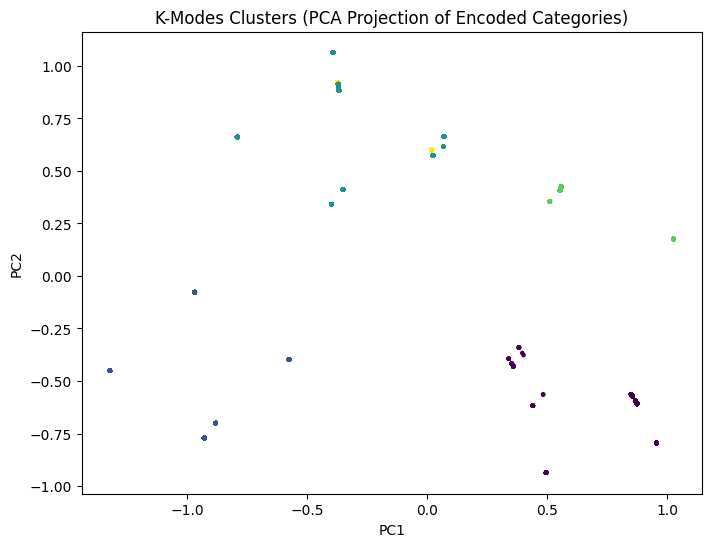

In [26]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# one-hot encode the categorical data for visualization only
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_kmodes_encoded = encoder.fit_transform(df_kmodes)

# reduce to 2D for plotting
pca = PCA(n_components=2)
X_kmodes_pca = pca.fit_transform(X_kmodes_encoded)

plt.figure(figsize=(8,6))
plt.scatter(X_kmodes_pca[:, 0], X_kmodes_pca[:, 1], c=kmodes_clusters, s=5)
plt.title("K-Modes Clusters (PCA Projection of Encoded Categories)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

# K-Models Comparison

## Comparison of Base Clustering Models

We compared three baseline clustering methods on the UNSW-NB15 network traffic dataset: K-Prototypes, K-Means, and K-Modes. Each model captures a different view of the data because the dataset contains both numerical and categorical features.

### K-Prototypes
K-Prototypes is the most natural baseline for this dataset because it can handle both numerical and categorical features together. In our results, however, most clusters remained fairly mixed. Four of the five clusters were still majority Normal, while one large cluster became more attack-heavy and was dominated by Generic traffic. This suggests that K-Prototypes does capture broad structure in the mixed dataset, but it does not cleanly separate the attack categories under the current off-the-shelf implementation.

### K-Means
K-Means only uses numerical features, so it focuses on behavioral intensity patterns such as rate, load, packet counts, bytes, and timing-related variables. Out of the three baseline methods, K-Means produced the clearest separation. It isolated a strongly Generic-heavy cluster, a strongly Exploit-heavy cluster, and additional clusters that were more normal-heavy. Its PCA visualization also showed the clearest continuous geometric structure, suggesting that many attack patterns differ meaningfully in their numerical behavior.

### K-Modes
K-Modes only uses categorical features, specifically protocol, service, and state. As a result, it groups traffic by connection-type signatures rather than by behavioral magnitude. The results still showed meaningful structure, including a strongly Generic-heavy cluster and a strongly Normal-heavy cluster, but several clusters remained mixed. Its PCA projection looked more discrete and island-like, which is expected because the visualization is based on one-hot encoded categorical data rather than continuous numerical space.

### Overall Comparison
Overall, K-Means produced the strongest empirical separation in our current results, especially for Generic and Exploit-heavy traffic. K-Modes was still useful, but it was limited by only seeing categorical connection identity features. K-Prototypes was the most conceptually appropriate for the mixed dataset, yet it still produced broad and overlapping clusters. Together, these results suggest that simple clustering methods can reveal useful structure in network traffic, but they struggle to fully capture the complexity of the data.

## Why the Base Models Struggle

These baseline models struggle for different reasons. K-Means discards categorical features, K-Modes discards numerical behavior, and K-Prototypes, while more flexible, still relies on relatively simple prototype-based cluster formation. Real network traffic is noisy, overlapping, and nonlinear, and many malicious behaviors resemble normal traffic in some features while differing only in subtle feature combinations.

## Why We Move to a Neural Network

Because of these limitations, we move to a neural network as a stronger next step. The neural network can combine scaled numerical features with encoded categorical features and learn a more expressive internal representation of the data. This allows the model to capture nonlinear interactions and more complex patterns than the baseline clustering methods. In other words, the clustering models help us explore the structure of the traffic, while the neural network helps us learn features that are better suited for separating attack behavior from normal behavior.

# Neural Network + Clustering: An Alternative to Common Methods?

The first step is to scale down the dataset. We do this because we want to make features comparable so the model doesn't get biased by magnitude differences. For example, we have values (like sbytes) that are in the millions, whereas duration is in a few seconds. For k-means clustering (without scaling) the model will think that sbytes is wayyyy more important than duration, which may or may not be true. Distance calculations (like in k means etc) are dominated by large numbers...

So we need to scale to ensure each feature contributes fairly to learning

Steps to take:

1. Split features
   - numerical
   - categorical

2. Numerical pipeline:
   - log transform (if skewed)
   - StandardScaler

3. Categorical pipeline:
   - OneHotEncoder
   - (NO scaling)

4. Combine features

5. Feed into neural network

6. Extract learned features

7. Run k-means

Each notebook runs its own kernel so no variable declarations here will mess up declarations in the main file. Later on when I put this all back into the main file, we will need to remove the import stuff since it is already in the main file

## Splitting Features, Scaling / Encoding

In [ ]:
import kagglehub
#this is the UNSW_NB15 dataset which is more modern
path = kagglehub.dataset_download("mrwellsdavid/unsw-nb15")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\Owner\.cache\kagglehub\datasets\mrwellsdavid\unsw-nb15\versions\1


In [ ]:
#inspect files
import os
os.listdir(path)
#we see all of the fils that we could've downloaded on kaggle

['NUSW-NB15_features.csv',
 'UNSW-NB15_1.csv',
 'UNSW-NB15_2.csv',
 'UNSW-NB15_3.csv',
 'UNSW-NB15_4.csv',
 'UNSW-NB15_LIST_EVENTS.csv',
 'UNSW_NB15_testing-set.csv',
 'UNSW_NB15_training-set.csv']

In [ ]:
#but we really only want the training and testing set
import pandas as pd
train_df = pd.read_csv(os.path.join(path, "UNSW_NB15_training-set.csv"))
test_df = pd.read_csv(os.path.join(path, "UNSW_NB15_testing-set.csv"))

#for OUR project we want to combine both of these because more data = better feature learning, and clustering benefits from more samples

df_og = pd.concat([train_df, test_df], axis = 0)

In [ ]:
#we need to split our data into categorical and numerical. We will apply one hot encoding on the categorical, and then we will scale the numerical features.
#note that WE ARE NOT scaling the categorical features. This would ruin their semantic meaning.
#we scale the numerical features because they differ vastly in scale... which is bad

#remember that we are using labels so we can use df_og.copy() to create a dataframe of categorical and a dataframe of numerical

df_cat = df_og[['proto', 'service', 'state']].copy() #we want to make a copy of the og datafram with only the categorical features in columns 1,2,3
df_num = df_og.drop(columns=['proto', 'service', 'state', 'id', 'attack_cat']).copy() #make a copy of the og dataframe with everything except the categorical features.

# #THIS IS ONE HOT ENCODING FOR CATEGORICAL FEATURES:
print("STARTING WITH ONE-HOT ENCODING FOR CATEGORICAL FEATURES...")

from sklearn.preprocessing import OneHotEncoder
import pandas as pd

encoder = OneHotEncoder(sparse_output=False)
# Requires a 2D array, so we use double brackets
encoded_array = encoder.fit_transform(df_cat) #these are our three categorical features that we need to encode

# Convert back to DataFrame with original names
encoded_df_cat = pd.DataFrame(encoded_array, columns=encoder.get_feature_names_out())

#THIS IS SCALING FOR NUMERICAL FEATURES:
#we want to use log transformation to reduce the influence of skewed features and outliers. then we can use standardization to scale the features to have a mean of 0 and a standard deviation of 1.
print("MOVING ON TO SCALING NUMERICAL FEATURES...")

from sklearn.preprocessing import FunctionTransformer
import numpy as np
transformer = FunctionTransformer(np.log1p) #log1p is used to handle zero values in the data, as log(0) is undefined. It computes log(1 + x), which allows us to apply the log transformation without encountering issues with zero values.
df_num_transformed = transformer.transform(df_num) #this applies the log transformation to all the numerical features in our df_num dataframe.

#now we need to take the log transformed data and standardize it using StandardScaler
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_df_num_transformed = scaler.fit_transform(df_num_transformed) #this standardizes the log transformed data to have a mean of 0 and a standard deviation of 1.




STARTING WITH ONE-HOT ENCODING FOR CATEGORICAL FEATURES...
MOVING ON TO SCALING NUMERICAL FEATURES...


In [ ]:
#check if we have one hot encoded correctly
print(encoded_df_cat.shape)
print(df_cat.nunique())

#based on the output, we now have 157 columns. This indicated we've done it correctly because the og data has 133 unique proto, 13 unique service, and 11 unique state. 
#so each unique value in our df_cat became it's own one-hot column!

#check if we have scaled correctly
print(scaled_df_num_transformed.shape)
print(scaled_df_num_transformed.mean(axis=0)) #should be close to 0 because we standardized the data to have a mean of 0
print(scaled_df_num_transformed.std(axis=0)) #should be close to 1


# the output indicates that we have successfully scaled our numerical features to have a mean of 0 and a standard deviation of 1, which is what we wanted to achieve with standardization.

(257673, 157)
proto      133
service     13
state       11
dtype: int64
(257673, 40)
[ 1.76482344e-17 -1.97660226e-16 -5.64743502e-17  5.64743502e-17
 -1.12948700e-16  9.88301128e-17 -7.34166552e-16 -1.12948700e-16
  0.00000000e+00  1.97660226e-16  8.47115252e-17 -5.64743502e-17
 -3.52964688e-17 -1.34126582e-16  2.04719519e-16 -2.11778813e-17
 -4.23557626e-17  1.97660226e-16 -2.11778813e-16 -1.69423050e-16
 -7.05929377e-18 -7.05929377e-18  1.41185875e-17 -4.07674215e-16
 -8.47115252e-17  1.94130579e-17  4.94150564e-17  3.84731510e-16
  1.69423050e-16  3.10608926e-16  2.82371751e-17  5.64743502e-17
  4.23557626e-17  8.73587604e-17  1.50009993e-17  2.82371751e-17
 -8.47115252e-17  1.48245169e-16 -1.76482344e-17  1.69423050e-16]
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


## Combining Features (to feed into Neural Network)

so now that we have our two separate (approrpiately scaled / encoded) dataframes. We can combine them to feed them to the neural network.

In [ ]:
scaled_encoded_combined = np.hstack([encoded_df_cat, scaled_df_num_transformed]) 
#this combines the one hot encoded categorical features and the scaled numerical features into one array that we can use for our neural network. 
#we use hstack to stack them horizontally, meaning we are adding columns to our dataset. The one hot encoded features will be on the left and the scaled numerical features will be on the right. 
#this way we preserve row alignment.

print(scaled_encoded_combined.shape) #this should have the same number of rows as our original dataframe and the number of columns should be the sum of the one hot encoded columns and the scaled numerical columns.

(257673, 197)


the output indicates we have succesfully combined the two. we have the same number of rows as outputted above, and the colums is 197 = 157+40 which is also outputted above

## Neural Network (using combined dataframes)

the combined dataframe is called scaled_encoded_combined

We are going to take a base model and edit it to fit our needs. We will use pyTorch "Feedforward Neural Network" because our dataset is tabular, mixed, not sequential and not spatial. This is the standard model for these types of datasets.

In [ ]:
%pip install torch

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


we want to use a neural network to learn a lower-dimensional representation of the data that captures important behavioral patterns. This allows clustering to operate on a more structured feature space.”

Feedforward Neural Networks (FNN) are effective for feature selection. This is what we want to do, so we will use FFN as seen below 

In [ ]:
import torch
import torch.nn as nn

# Define the network architecture
class FeedForwardNN(nn.Module):
    def __init__(self, input_size, num_classes):
        super(FeedForwardNN, self).__init__()

        #this is the encoder which is in charge of learning a compressed representation of our data. It takes in the input size, which is the number of features we have in our dataset, and outputs a compressed representation of our data that we can use for classification.

        self.encoder = nn.Sequential(nn.Linear(input_size, 128), #this is the first layer of our encoder, it takes in the input size and outputs 128 features
                                     nn.ReLU(), #this is the activation function for the first layer, it introduces non-linearity to the model which allows it to learn more complex patterns in the data

                                     nn.Linear(128,64), #then the second layer of our encoder takes in the 128 features from the first layer and outputs 64 features
                                     nn.ReLU(), #then we apply another activation function to introduce more non-linearity.

                                     nn.Linear(64,32), #this is the bottleneck layer of our encoder, it takes in the 64 features from the second layer and outputs 32 features. This is where we are learning a compressed representation of our data.
                                     nn.ReLU(),
        ) #finally we apply another activation function to the bottleneck layer to introduce more non-linearity.
                                     
        #this is the classifier, which is in charge of classifying our data based on the compressed representation learned by the encoder

        self.classifier = nn.Sequential(nn.Linear(32,64), #this is the first layer of our classifier, it takes in the 32 features from the bottleneck layer and outputs 64 features
                                        nn.ReLU(), #this is the activation function for the first layer of our classifier, it introduces non-linearity to the model which allows it to learn more complex patterns in the data
    
                                        nn.Linear(64,num_classes) #then the second layer of our classifier takes in the 64 features from the first layer and outputs num_classes features, which is the number of classes we have in our dataset. This is where we are learning to classify our data based on the compressed representation learned by the encoder.

        )
    
    def forward(self, x):
        features = self.encoder(x) #first we pass our input through the encoder to get the compressed representation of our data
        out = self.classifier(features) #then we pass the compressed representation through the classifier to get our final output
        return out
    
    def extract_features(self, x):
        return self.encoder(x) #this is a helper function that allows us to extract the compressed features from the encoder, which we can use for clustering later on.

X_tensor = torch.tensor(scaled_encoded_combined, dtype=torch.float32)

# Initialize model
input_size = scaled_encoded_combined.shape[1] #this is the number of features we have in our dataset after one hot encoding and scaling
num_classes = len(df_og['attack_cat'].unique()) #this is the number of unique classes we have in our target variable, which is the attack category
model = FeedForwardNN(input_size, num_classes)
outputs = model(X_tensor)



In [ ]:
print("MODEL OUTPUTS:")
print(outputs)

print("PREDICTED CLASSES:")
predicted_classes = torch.argmax(outputs, dim=1)
print(predicted_classes)

probabilities = torch.softmax(outputs, dim=1)
print("PROBABILITIES:")
print(probabilities)

MODEL OUTPUTS:
tensor([[-0.0401,  0.1283, -0.0026,  ..., -0.0384,  0.0237, -0.0625],
        [-0.0427,  0.1269, -0.0020,  ..., -0.0374,  0.0229, -0.0623],
        [-0.0422,  0.1278, -0.0022,  ..., -0.0384,  0.0234, -0.0626],
        ...,
        [-0.0431,  0.1343, -0.0074,  ..., -0.0382,  0.0225, -0.0632],
        [-0.0377,  0.1352,  0.0016,  ..., -0.0341,  0.0213, -0.0598],
        [-0.0379,  0.1351,  0.0012,  ..., -0.0342,  0.0216, -0.0597]],
       grad_fn=<AddmmBackward0>)
PREDICTED CLASSES:
tensor([1, 1, 1,  ..., 1, 1, 1])
PROBABILITIES:
tensor([[0.0961, 0.1138, 0.0998,  ..., 0.0963, 0.1025, 0.0940],
        [0.0959, 0.1137, 0.0999,  ..., 0.0964, 0.1024, 0.0941],
        [0.0960, 0.1137, 0.0999,  ..., 0.0963, 0.1025, 0.0940],
        ...,
        [0.0958, 0.1144, 0.0993,  ..., 0.0963, 0.1023, 0.0939],
        [0.0961, 0.1142, 0.0999,  ..., 0.0964, 0.1019, 0.0940],
        [0.0961, 0.1142, 0.0999,  ..., 0.0964, 0.1019, 0.0940]],
       grad_fn=<SoftmaxBackward0>)


BUT! Notice that the predicted classes are all the same , and the probabilities are essentially the same as well. This is because we have only ran our model once and we are not training it. 

## Training the Model

In [ ]:
#this is the target variable that we want to predict, which is the attack category. We need to convert it to a tensor so we can use it for training our model.
y_encoded = df_og['attack_cat'].astype('category').cat.codes
y_tensor = torch.tensor(y_encoded.values, dtype=torch.long)

In [ ]:
from sklearn.model_selection import train_test_split

#this is where we split our data into a training set and a testing set. We want to use the training set to train our model and the testing set to evaluate our model's performance. We use stratify=y to ensure that the distribution of classes in the train and test sets is similar to the distribution in the original dataset. This is important for classification tasks to prevent bias in the model training and evaluation. By setting stratify=y, we ensure that the proportion of each class in the target variable y is maintained in both the training and testing sets.
X= scaled_encoded_combined
y= y_encoded.values #this is our target variable, which is the attack category. We want to predict this based on the features in X.

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y) #stratify is used to ensure that the distribution of classes in the train and test sets is similar to the distribution in the original dataset. This is important for classification tasks to prevent bias in the model training and evaluation. By setting stratify=y, we ensure that the proportion of each class in the target variable y is maintained in both the training and testing sets.

In [ ]:
from torch.utils.data import TensorDataset, DataLoader

dataset = TensorDataset(
    torch.tensor(X_train, dtype=torch.float32),
    torch.tensor(y_train, dtype=torch.long)
) #this creates a dataset object that combines our input features (X_tensor) and our target labels (y_tensor) into a single object that we can use for training our neural network. We convert X_train to a tensor of type float32 and y_train to a tensor of type long, which is the appropriate data type for our target labels in a classification task.
loader = DataLoader(dataset, batch_size=64, shuffle=True) #this creates a dataloader object that allows us to iterate through our dataset in batches of 64 and shuffle the data at each epoch to improve training.

In [ ]:
#now we have our model outputs and our target labels, we can calculate the loss and optimize our model using backpropagation. 
#we will use cross-entropy loss for multi-class classification and Adam optimizer for optimization.

criterion = nn.CrossEntropyLoss() #this is the loss function. it measures how well the predictions match true labels
optimizer = torch.optim.Adam(model.parameters(), lr=0.005) #creates optimizer (adam) which updates the model's weights to min loss

num_epochs = 30 #this is the number of times the model will see the entire dataset during training

for epoch in range(num_epochs): #for as many epochs as we have
    total_loss = 0
    
    for batch_X, batch_y in loader: #for each batch of data in our dataloader
        outputs = model(batch_X) #run the data through the model to get predictions
        loss = criterion(outputs, batch_y) #calculate how far off predictions are from true labels
        
        optimizer.zero_grad() #clears old gradient (the one from last step)
        loss.backward() #computes gradient of loss with respect to model parameters (weights)
        optimizer.step()#updates the model parameters using gradient
        
        total_loss += loss.item()
    
    print(f"Epoch {epoch+1}, Loss: {total_loss/len(loader):.4f}") #shows the loss for each epoch

Epoch 1, Loss: 0.3406
Epoch 2, Loss: 0.3257
Epoch 3, Loss: 0.3279
Epoch 4, Loss: 0.3259
Epoch 5, Loss: 0.3287
Epoch 6, Loss: 0.3560
Epoch 7, Loss: 0.3288
Epoch 8, Loss: 0.3531
Epoch 9, Loss: 0.3290
Epoch 10, Loss: 0.3260
Epoch 11, Loss: 0.3295
Epoch 12, Loss: 0.3249
Epoch 13, Loss: 0.3318
Epoch 14, Loss: 0.3267
Epoch 15, Loss: 0.3299
Epoch 16, Loss: 0.3313
Epoch 17, Loss: 0.3392
Epoch 18, Loss: 0.3281
Epoch 19, Loss: 0.3245
Epoch 20, Loss: 0.3252
Epoch 21, Loss: 0.3260
Epoch 22, Loss: 0.3253
Epoch 23, Loss: 0.3268
Epoch 24, Loss: 0.3368
Epoch 25, Loss: 0.3310
Epoch 26, Loss: 0.3248
Epoch 27, Loss: 0.3249
Epoch 28, Loss: 0.3378
Epoch 29, Loss: 0.3302
Epoch 30, Loss: 0.3275


Two things worth noting:
- Adam Optimizer: An algorithm that trains learning models by adjusting the learning rates individually. It takes large steps in flat areas and smaller steps in noisy/steep areas. 

- With the outputs that we have, we notice that the epoch loss values are decreasing. This indicates that the model is actively learning and improving it's performance. 
    - Typically we would see faster rates of decrease. So why is our model not doing so?
        - It turns out that my learning rate was too low. Furthermore, there was no "batching" which essentially just maximizes efficieny and learning.

## Neural Network Evaluation *Accuracy Score!*

In [ ]:
#NEURAL NETWORK EVALUATION:

model.eval()

with torch.no_grad():
    test_outputs = model(torch.tensor(X_test, dtype=torch.float32))
    preds = torch.argmax(test_outputs, dim=1).numpy()

nn_accuracy = (preds == y_test).mean()
print("Neural Network Accuracy:", nn_accuracy)

Neural Network Accuracy: 0.8753274473658679


The neural network accuracy measures how well our trained model predicts the correct attack category (or class) on the test data. Specifically, it is the proportion of test samples for which the predicted class matches the true label.

What it is computing:

For each test sample, the model outputs a predicted class.
Accuracy = (Number of correct predictions) / (Total number of test samples).

What it means:

High accuracy means your neural network has learned patterns in the data that generalize well to unseen samples, so it can correctly classify most test cases.
Low accuracy means the model is not capturing the underlying structure, possibly due to insufficient training, poor features, or an overly complex/simple model.

## Taking the Output from Neural Network (FeedForwardNN) and Clustering

In [ ]:
#feature extraction for clustering from neural network (the bottleneck layer of our encoder is where we learn a compressed representation of our data, so we can use the extract_features function to get those features and then use them for clustering)
model.eval()

with torch.no_grad():
    train_features = model.extract_features(torch.tensor(X_train, dtype=torch.float32)).numpy()
    test_features  = model.extract_features(torch.tensor(X_test, dtype=torch.float32)).numpy()

In [ ]:
#all this is doing is taking the output from the bottleneck layer of our encoder and using it as features for clustering. 
# We are doing this because we want to see if the neural network has learned a useful representation of our data that can be used for clustering. 
# If the clusters we get from these features are meaningful, it suggests that the neural network has learned a good representation of the data that captures important patterns and relationships.
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=10, random_state=42)
train_clusters = kmeans.fit_predict(train_features)
test_clusters = kmeans.predict(test_features)

print("CLUSTER ASSIGNMENTS:")
print("Train Clusters:", train_clusters)
print("Test Clusters:", test_clusters)

CLUSTER ASSIGNMENTS:
Train Clusters: [5 1 5 ... 7 9 5]
Test Clusters: [4 6 5 ... 5 5 5]


## Mapping Clusters to Attack Classes

In [ ]:
%pip install collections

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement collections (from versions: none)

[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for collections


In [ ]:
#this is where we are creating a mapping from cluster ids to the most common true label in that cluster. 
# This allows us to interpret the clusters in terms of the original labels and evaluate how well the clustering corresponds to the true classes in our dataset.
from collections import Counter
import numpy as np
cluster_to_label = {}
for cluster_id in range(10): #for each cluster id from 0 to 9
    indices = np.where(train_clusters == cluster_id)[0] #find the indices of the samples in the training set that belong to the current cluster
    cluster_labels = y_train[indices] #get the true labels of those samples
    
    if len(indices) == 0: #if there are any samples in this cluster
       continue
    most_common_label = Counter(cluster_labels).most_common(1)[0][0] #find the most common true label among those samples
    cluster_to_label[cluster_id] = most_common_label #assign the most common label to the cluster id in our mapping dictionary

## Clustering-Based Classification *Accuracy Score!*

In [ ]:
cluster_preds = np.array([cluster_to_label[c] for c in test_clusters]) #this creates an array of predicted labels for the test set based on the cluster assignments. If a cluster id is not found in our mapping dictionary, we assign it a default value of -1.
cluster_accuracy = (cluster_preds == y_test).mean()

print("Cluster-based Classification Accuracy:", cluster_accuracy)

Cluster-based Classification Accuracy: 0.7251964684195207


The cluster-based classification accuracy tells us how well our clustering approach (using KMeans on neural network features) can group data points in a way that matches the true attack categories.

- What it is computing:
    - Each cluster is mapped to the most common true label among its members.
    - For each test sample, we assign the predicted label based on its cluster.
    - Accuracy = (Number of test samples where the cluster’s mapped label matches the true label) / (Total number of test samples).
- What it means:

    - High cluster-based accuracy means the neural network has learned a feature space where similar attacks are grouped together, and clustering can recover the true categories well.
    - Low accuracy means the learned features do not separate the classes clearly, or the clustering does not align with the true categories.

- In the grand scheme:

    - This accuracy measures how well unsupervised clustering (on learned features) can approximate the true class structure.
    - It shows the effectiveness of the neural network as a feature extractor for downstream tasks like anomaly detection or unsupervised classification.
    - If cluster-based accuracy is close to neural network accuracy, it means the learned features are highly informative and structure the data well for clustering.- 

## PCA Visualization

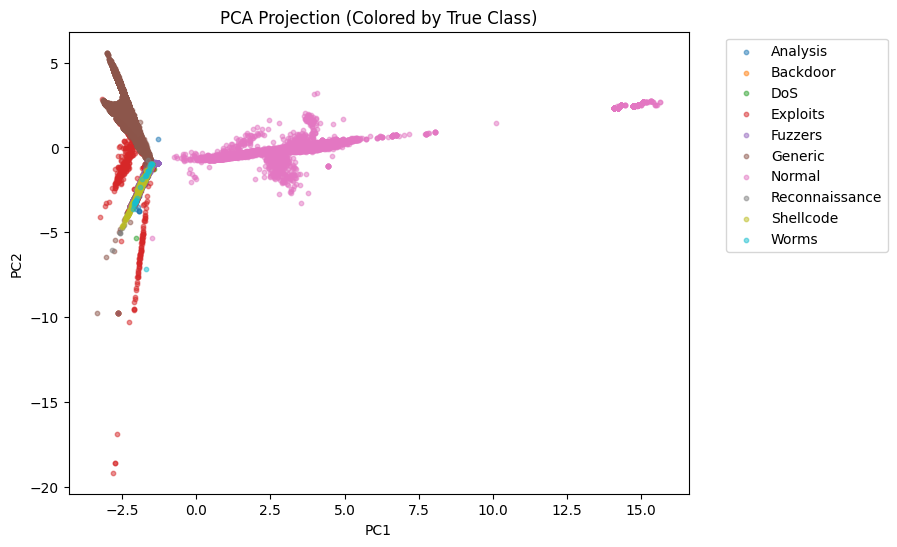

In [ ]:
# Visualize KMeans Clustering Results

import matplotlib.pyplot as plt

from sklearn.decomposition import PCA

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
train_features_scaled = scaler.fit_transform(train_features)
test_features_scaled = scaler.transform(test_features)


# Assume kmeans has been fitted to learned_features and labels are in kmeans.labels_
# Reduce features to 2D for visualization

pca = PCA(n_components=2)

features_2d = pca.fit_transform(test_features_scaled)

label_mapping = dict(enumerate(df_og['attack_cat'].astype('category').cat.categories))


plt.figure(figsize=(8,6))

for label in np.unique(y_test):
    idx = y_test == label
    plt.scatter(
        features_2d[idx, 0],
        features_2d[idx, 1],
        label=label_mapping[label],
        alpha=0.5,
        s=10
    )

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title("PCA Projection (Colored by True Class)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

## t-SNE Visualization

In [ ]:
%pip install TSNE

Defaulting to user installation because normal site-packages is not writeable
     ---------------------------------------- 0.0/547.6 kB ? eta -:--:--
     -------------------------------------- 547.6/547.6 kB 3.7 MB/s eta 0:00:00
  Installing build dependencies: started
  Installing build dependencies: finished with status 'error'
Note: you may need to restart the kernel to use updated packages.


  error: subprocess-exited-with-error
  
  × pip subprocess to install build dependencies did not run successfully.
  │ exit code: 1
  ╰─> [63 lines of output]
      Ignoring numpy: markers 'python_version < "3.7"' don't match your environment
           ---------------------------------------- 0.0/5.1 MB ? eta -:--:--
           ---------------- ----------------------- 2.1/5.1 MB 14.7 MB/s eta 0:00:01
           ---------------------------------------  5.0/5.1 MB 14.4 MB/s eta 0:00:01
           ---------------------------------------- 5.1/5.1 MB 12.3 MB/s eta 0:00:00
        Installing build dependencies: started
        Installing build dependencies: finished with status 'done'
        Getting requirements to build wheel: started
        Getting requirements to build wheel: finished with status 'done'
        Preparing metadata (pyproject.toml): started
        Preparing metadata (pyproject.toml): finished with status 'error'
        error: subprocess-exited-with-error
      
      

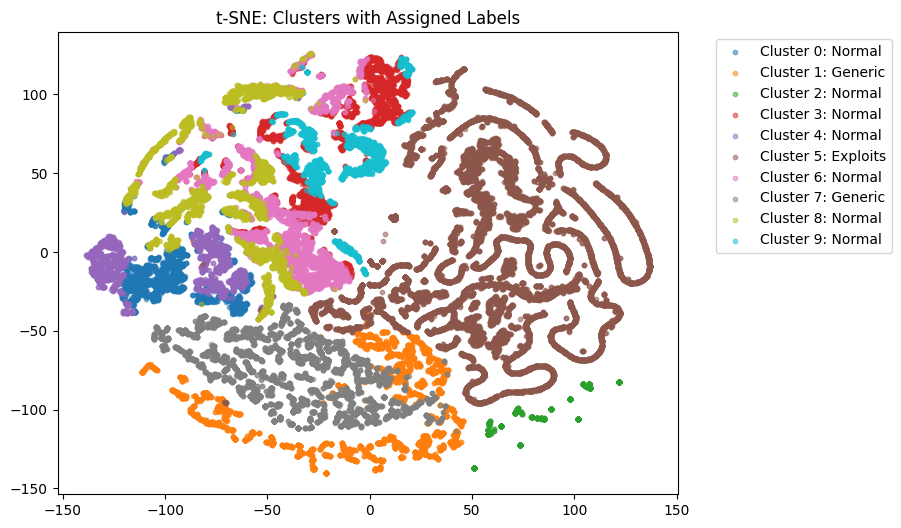

In [ ]:
from sklearn.manifold import TSNE

cluster_names = {
    c: label_mapping[label]
    for c, label in cluster_to_label.items()
}

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
features_2d = tsne.fit_transform(test_features_scaled)

plt.figure(figsize=(8,6))

for cluster in np.unique(test_clusters):
    idx = test_clusters == cluster
    plt.scatter(
        features_2d[idx, 0],
        features_2d[idx, 1],
        label=f"Cluster {cluster}: {cluster_names.get(cluster, 'Unknown')}",
        alpha=0.5,
        s=10
    )

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title("t-SNE: Clusters with Assigned Labels")
plt.show()

## More Visualization of Results

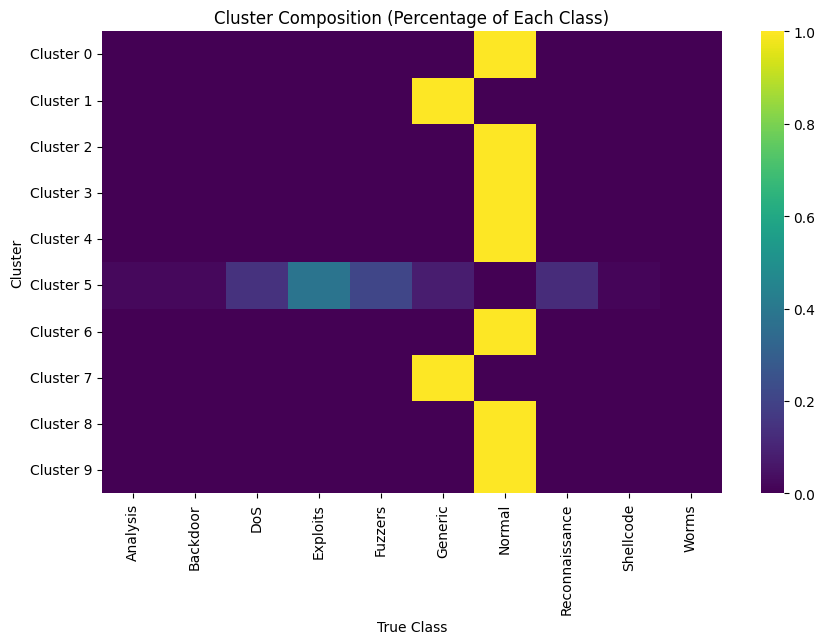

In [ ]:
import seaborn as sns

ct = pd.crosstab(test_clusters, y_test, normalize='index')
plt.figure(figsize=(10,6))

sns.heatmap(
    ct,
    cmap="viridis",
    xticklabels=[label_mapping[i] for i in ct.columns],
    yticklabels=[f"Cluster {i}" for i in ct.index]
)

plt.title("Cluster Composition (Percentage of Each Class)")
plt.xlabel("True Class")
plt.ylabel("Cluster")
plt.show()

In [ ]:
%pip install seaborn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


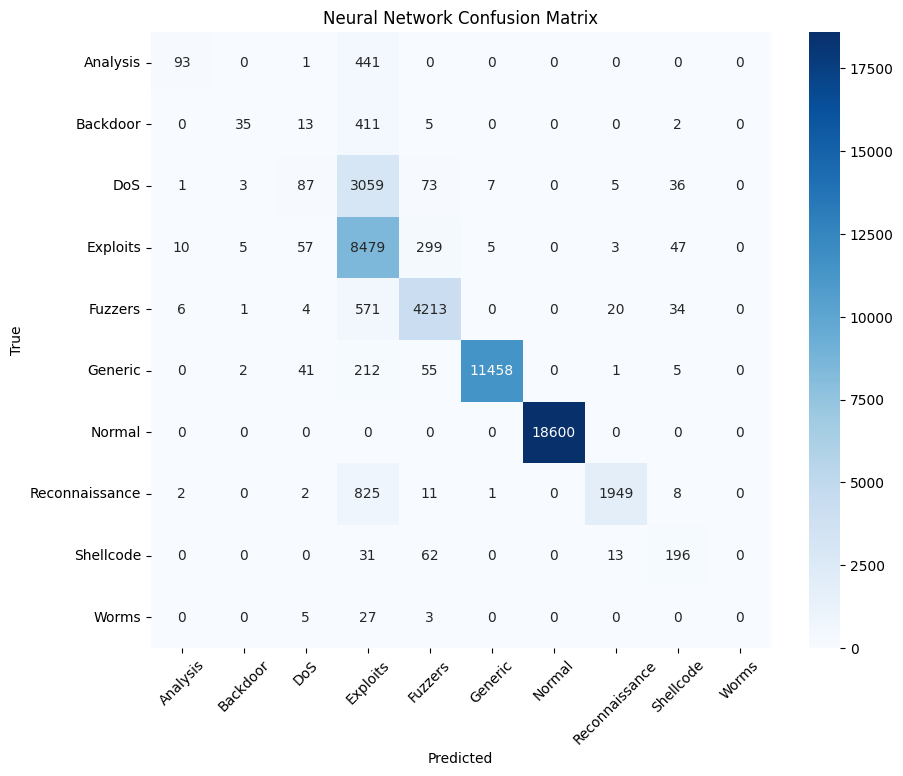

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, preds)

plt.figure(figsize=(10,8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_mapping.values(),
    yticklabels=label_mapping.values()
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Neural Network Confusion Matrix")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()

# Overall Conclusions

Overall, this project demonstrates that clustering is effective for uncovering underlying behavioral patterns in network traffic, but not for cleanly separating normal and malicious activity. Across multiple models and configurations, consistent trends emerged: attack traffic tends to form high-frequency, low-volume interaction patterns, while normal traffic reflects more complex and variable exchanges. However, significant overlap between clusters reveals a key challenge in intrusion detection—many attacks closely resemble legitimate behavior. By incorporating feature learning through a neural network, the project shows that transforming the data into a more meaningful representation can improve cluster structure and interpretability. Ultimately, the work highlights both the strengths and limitations of unsupervised learning in cybersecurity, emphasizing that clustering is best used as a tool for exploration and insight rather than definitive classification.